# CNN Baseline: OCT-C8 Classification

We'll train a CNN to classify the images from C8 and save it for Grad-CAM analysis

In [3]:
from pathlib import Path
import sys
import torch


PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# DATA_DIR = PROJECT_ROOT / "data/oct_c8/RetinalOCT_Dataset/RetinalOCT_Dataset"
DATA_DIR = PROJECT_ROOT / "data/RetinalOCT_Dataset"

RESULTS_DIR = PROJECT_ROOT / "results"
MODEL_DIR = RESULTS_DIR / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Data exists:", DATA_DIR.exists())
print("\n")
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

device

Project root: C:\Users\u0667281\Desktop\JMA\barcoding-amd
Data dir: C:\Users\u0667281\Desktop\JMA\barcoding-amd\data\RetinalOCT_Dataset
Data exists: True




device(type='cpu')

In [4]:
# Check classes
from src.dataset import get_oct_c8_dataloaders

train_loader, val_loader, test_loader, class_names = get_oct_c8_dataloaders(
    DATA_DIR,
    batch_size=32,
    num_workers=0
)

class_names

['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']

In [5]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[:10])

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([3, 7, 6, 5, 1, 5, 7, 7, 3, 3])


In [6]:
from src.models import build_resnet50

num_classes = len(class_names)

model = build_resnet50(
    num_classes=num_classes,
    pretrained=True,
    freeze_backbone=True
)

model = model.to(device)

model.fc

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\u0667281/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 114MB/s] 


Linear(in_features=2048, out_features=8, bias=True)

In [7]:
# check forwards pass
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print(outputs.shape)

torch.Size([32, 8])


In [8]:
import torch.nn as nn
import torch.optim as optim

from src.train import train_model

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

checkpoint_path = MODEL_DIR / "resnet50_oct_c8_frozen.pt"

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=3,
    checkpoint_path=checkpoint_path
)
# freeze backbone = true, so  this trains only the final classification layer first.

Epoch 1/3 | Train Loss: 0.8405 | Train Acc: 0.7398 | Val Loss: 0.5571 | Val Acc: 0.8179
Saved best model to C:\Users\u0667281\Desktop\JMA\barcoding-amd\results\models\resnet50_oct_c8_frozen.pt
Epoch 2/3 | Train Loss: 0.5187 | Train Acc: 0.8262 | Val Loss: 0.4624 | Val Acc: 0.8389
Saved best model to C:\Users\u0667281\Desktop\JMA\barcoding-amd\results\models\resnet50_oct_c8_frozen.pt
Epoch 3/3 | Train Loss: 0.4422 | Train Acc: 0.8517 | Val Loss: 0.4168 | Val Acc: 0.8521
Saved best model to C:\Users\u0667281\Desktop\JMA\barcoding-amd\results\models\resnet50_oct_c8_frozen.pt


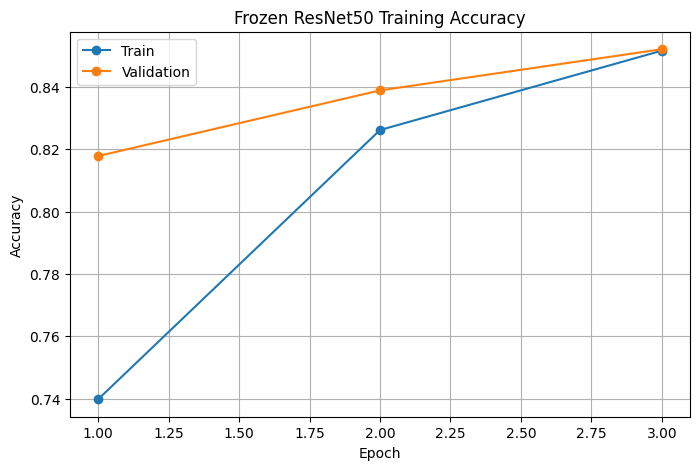

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train")
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Frozen ResNet50 Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()

The first ResNet50 experiment used ImageNet-pretrained weights with the convolutional backbone frozen. Only the final classification layer was trained. After three epochs, validation accuracy reached approximately 85 percent. This indicates that pretrained CNN features transfer reasonably well to retinal OCT classification, even before fine-tuning the deeper convolutional layers.


In [10]:
from src.train import evaluate

# Reload best checkpoint
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

test_loss, test_acc = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4180
Test Accuracy: 0.8600


In [11]:
import torch
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         AMD       1.00      1.00      1.00       350
         CNV       0.83      0.74      0.79       350
         CSR       0.94      0.95      0.95       350
         DME       0.82      0.79      0.81       350
          DR       0.92      0.91      0.92       350
      DRUSEN       0.70      0.71      0.70       350
          MH       0.94      0.94      0.94       350
      NORMAL       0.74      0.83      0.78       350

    accuracy                           0.86      2800
   macro avg       0.86      0.86      0.86      2800
weighted avg       0.86      0.86      0.86      2800



## Fine-Tuning the Last ResNet Block

The frozen-backbone model achieved good classification accuracy, but Grad-CAM maps were sometimes diffuse. To make the model more OCT-specific, we next fine-tune the final ResNet block (`layer4`) while keeping earlier layers frozen.

In [13]:
# Load a fresh pretrained model
from src.models import build_resnet50

model_ft = build_resnet50(
    num_classes=len(class_names),
    pretrained=True,
    freeze_backbone=False
)

model_ft = model_ft.to(device)

In [14]:
# Freeze everything, then unfreeze layer4 and fc
for param in model_ft.parameters():
    param.requires_grad = False

for param in model_ft.layer4.parameters():
    param.requires_grad = True

for param in model_ft.fc.parameters():
    param.requires_grad = True

In [15]:
# check trainable params
trainable_params = sum(
    p.numel() for p in model_ft.parameters() if p.requires_grad
)

total_params = sum(
    p.numel() for p in model_ft.parameters()
)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")
print(f"Percent trainable: {100 * trainable_params / total_params:.2f}%")

Trainable parameters: 14,981,128
Total parameters: 23,524,424
Percent trainable: 63.68%


In [16]:
# define optimizer with a small learning rate
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-5
)

In [17]:
from src.train import train_model

checkpoint_path_ft = MODEL_DIR / "resnet50_oct_c8_layer4_finetuned.pt"

history_ft = train_model(
    model=model_ft,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_ft,
    device=device,
    num_epochs=3,
    checkpoint_path=checkpoint_path_ft
)

Epoch 1/3 | Train Loss: 1.3712 | Train Acc: 0.6161 | Val Loss: 0.6103 | Val Acc: 0.8543
Saved best model to C:\Users\u0667281\Desktop\JMA\barcoding-amd\results\models\resnet50_oct_c8_layer4_finetuned.pt
Epoch 2/3 | Train Loss: 0.4002 | Train Acc: 0.8842 | Val Loss: 0.2384 | Val Acc: 0.9314
Saved best model to C:\Users\u0667281\Desktop\JMA\barcoding-amd\results\models\resnet50_oct_c8_layer4_finetuned.pt
Epoch 3/3 | Train Loss: 0.2412 | Train Acc: 0.9236 | Val Loss: 0.1864 | Val Acc: 0.9386
Saved best model to C:\Users\u0667281\Desktop\JMA\barcoding-amd\results\models\resnet50_oct_c8_layer4_finetuned.pt


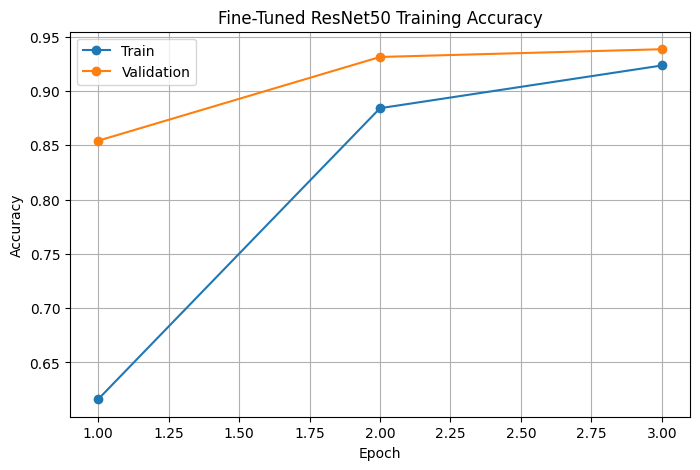

In [18]:
# plot fine tuning history
history_ft_df = pd.DataFrame(history_ft)

plt.figure(figsize=(8, 5))

plt.plot(
    history_ft_df["epoch"],
    history_ft_df["train_acc"],
    marker="o",
    label="Train"
)

plt.plot(
    history_ft_df["epoch"],
    history_ft_df["val_acc"],
    marker="o",
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuned ResNet50 Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# evaluation on test set
model_ft.load_state_dict(
    torch.load(checkpoint_path_ft, map_location=device)
)

test_loss_ft, test_acc_ft = evaluate(
    model=model_ft,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Fine-tuned Test Loss: {test_loss_ft:.4f}")
print(f"Fine-tuned Test Accuracy: {test_acc_ft:.4f}")

Fine-tuned Test Loss: 0.1849
Fine-tuned Test Accuracy: 0.9396


In [20]:
all_preds_ft = []
all_labels_ft = []

model_ft.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model_ft(images)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds_ft.extend(preds)
        all_labels_ft.extend(labels.numpy())

all_preds_ft = np.array(all_preds_ft)
all_labels_ft = np.array(all_labels_ft)

In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels_ft,
        all_preds_ft,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         AMD       1.00      1.00      1.00       350
         CNV       0.89      0.85      0.87       350
         CSR       1.00      1.00      1.00       350
         DME       0.95      0.88      0.91       350
          DR       0.99      1.00      1.00       350
      DRUSEN       0.84      0.85      0.84       350
          MH       0.99      0.99      0.99       350
      NORMAL       0.86      0.95      0.90       350

    accuracy                           0.94      2800
   macro avg       0.94      0.94      0.94      2800
weighted avg       0.94      0.94      0.94      2800

